In [25]:
from data import SQGData     

sqg_data = SQGData(data_std=2660)
data = sqg_data.get_field()
data_phy = sqg_data.get_field("truth", normalized=True)

✅ SQG 数据加载完成: shape = (1001, 2, 64, 64), data_std = 2660


In [26]:
import numpy as np

print(np.std(data_phy))
print(np.std(data))

0.9884335147820422
0.9985503130563023


In [27]:

import torch
import matplotlib.pyplot as plt

def map_latent_to_physical(
    latent,
    sampler,
    device=None,
    data_std=1,
    return_torch=False
):
    """
    Map latent field(s) → physical field(s) using sampler.sample, with shape checks.

    Acceptable input shapes:
      - (W, H)                    : single frame, level=0   → internally make (1, 2, W, H)
      - (T, W, H)                 : multi-frame, level=0    → internally make (T, 2, W, H)
      - (T, L, W, H),  L in {1,2} : level=0/0,1             → if L==1 duplicate to L==2

    Consistency check:
      - Require sampler.members == T  (T = number of frames).
        For single frame input (W,H), T=1 is required.

    Returns:
      - physical of shape (T, W, H); numpy.float32 by default, or torch.Tensor (CPU) if return_torch=True
    """

    # ---- device ----
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    elif isinstance(device, str):
        device = torch.device(device)

    # ---- to torch tensor ----
    x = latent
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x)
    if not isinstance(x, torch.Tensor):
        raise TypeError("latent must be a numpy array or a torch tensor.")

    x = x.to(torch.float32)

    # ---- normalize shapes ----
    # We standardize to shape (T, L, W, H) before calling sampler.sample
    if x.ndim == 2:
        # (W, H) → single frame, level=0 → (1, 1, W, H) then duplicate to (1, 2, W, H)
        W, H = x.shape
        x = x.unsqueeze(0).unsqueeze(0)     # (1, 1, W, H)
        x = x.repeat(1, 2, 1, 1)            # (1, 2, W, H)
        T = 1

    elif x.ndim == 3:
        # (T, W, H) → level=0 → (T, 1, W, H) then duplicate to (T, 2, W, H)
        T, W, H = x.shape
        x = x.unsqueeze(1)                  # (T, 1, W, H)
        x = x.repeat(1, 2, 1, 1)            # (T, 2, W, H)

    elif x.ndim == 4:
        # (T, L, W, H), L in {1,2}; if 1 → duplicate to 2
        T, L, W, H = x.shape
        if L == 1:
            x = x.repeat(1, 2, 1, 1)        # (T, 2, W, H)
        elif L != 2:
            raise ValueError(f"Expected level dimension L in {{1,2}}, got L={L}.")
        # else already (T, 2, W, H)

    else:
        raise ValueError(f"Unsupported latent ndim={x.ndim}. Expected 2/3/4 dims.")

    # ---- sampler.members consistency ----
    if not hasattr(sampler, "members"):
        raise ValueError("sampler has no attribute 'members'.")
    if sampler.members != T:
        raise ValueError(
            f"sampler.members ({sampler.members}) must equal number of frames T ({T})."
        )

    # ---- move to device and sample ----
    x = x.to(device)                         # (T, 2, W, H)
    y = sampler.sample(x)               # assume (T, 2, W, H)
    y0 = y[:, 0, ...] * float(data_std)  # take channel-0 and de-standardize → (T, W, H)

    y0_cpu = y0.detach().cpu()
    if return_torch:
        return y0_cpu
    else:
        return y0_cpu.numpy().astype(np.float32)


def visualize_and_rmse(
    phys_pred,
    phys_true,
    suptitle="Latent→Physical comparison",
    cmap="viridis"
):
    """
    Compare predicted vs true physical fields with RMSE and visualization.
    Supports:
      - Multi-frame: (T, W, H)
      - Single-frame: (W, H)  (requires sampler.members == 1)

    Inputs must be numpy arrays.
    """

    # ---------- Input checks ----------
    if not isinstance(phys_pred, np.ndarray) or not isinstance(phys_true, np.ndarray):
        raise TypeError("phys_pred and phys_true must be numpy arrays.")

  
    pred = phys_pred.astype(np.float32)
    true = phys_true.astype(np.float32)

    if pred.shape != true.shape:
        raise ValueError(f"Shape mismatch: pred {pred.shape} vs true {true.shape}")

    if pred.ndim != 3:
        raise ValueError(f"Expected shape (T,W,H), got {pred.shape}")

    T = pred.shape[0]

    # ---------- RMSE ----------
    diff = pred - true
    per_frame_rmse = np.sqrt(np.mean(diff**2, axis=(1, 2)))
    overall_rmse = float(np.sqrt(np.mean(diff**2)))

    print(f"[RMSE] overall = {overall_rmse:.6f}")
    if T <= 16:
        print("[RMSE] per-frame:", np.array2string(per_frame_rmse, precision=6, separator=", "))

    # ---------- Frame selection ----------

    # ---------- Plotting ----------
    ncols = 3
    nrows = T
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.6*nrows))

    if nrows == 1:
        axes = np.expand_dims(axes, 0)

    for idx in range(T):
        idx = max(0, min(T - 1, idx))

        vmin = min(true[idx].min(), pred[idx].min())
        vmax = max(true[idx].max(), pred[idx].max())

        im0 = axes[idx, 0].imshow(true[idx], cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        axes[idx, 0].set_title(f"Truth (t={idx})")
        plt.colorbar(im0, ax=axes[idx, 0], fraction=0.046, pad=0.04)

        im1 = axes[idx, 1].imshow(pred[idx], cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        axes[idx, 1].set_title(f"Pred (t={idx})")
        plt.colorbar(im1, ax=axes[idx, 1], fraction=0.046, pad=0.04)

        im2 = axes[idx, 2].imshow(np.abs(pred[idx] - true[idx]), cmap="bwr", origin="lower")
        axes[idx, 2].set_title(f"Diff  RMSE={per_frame_rmse[idx]:.4f}")
        plt.colorbar(im2, ax=axes[idx, 2], fraction=0.046, pad=0.04)

        for c in range(ncols):
            axes[idx, c].set_xticks([])
            axes[idx, c].set_yticks([])

    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

    return overall_rmse, per_frame_rmse


In [28]:
import numpy as np
import matplotlib.pyplot as plt



def _isotropic_spectrum(img):
    """
    Compute isotropic (radially-averaged) 2D power spectral density for one field.
    img: (H, W) float32/float64
    Returns:
        k_bins (1D), E_k (1D)  -- radial wavenumber and energy density
    """
    img = np.asarray(img, dtype=np.float32)
    H, W = img.shape

    # 2D FFT -> power spectrum (Parseval-consistent up to a constant factor)
    F = np.fft.fft2(img)
    P = np.abs(F) ** 2 / (H * W)  # normalize so scales comparable across sizes
    P = np.fft.fftshift(P)

    # Build radial bins
    ky = np.fft.fftshift(np.fft.fftfreq(H)) * H
    kx = np.fft.fftshift(np.fft.fftfreq(W)) * W
    KX, KY = np.meshgrid(kx, ky)
    KR = np.sqrt(KX**2 + KY**2)

    # Integer bins for isotropic average
    k_int = np.floor(KR).astype(np.int32)
    k_max = k_int.max()

    # Radial averaging with bincount
    Ek_sum = np.bincount(k_int.ravel(), weights=P.ravel(), minlength=k_max+1)
    Ek_num = np.bincount(k_int.ravel(), minlength=k_max+1)
    with np.errstate(invalid="ignore"):
        E_k = np.where(Ek_num > 0, Ek_sum / np.maximum(Ek_num, 1), 0.0)

    k_bins = np.arange(len(E_k), dtype=np.float32)
    # Remove k=0 if you prefer focusing on non-mean structure:
    # mask = k_bins > 0; k_bins, E_k = k_bins[mask], E_k[mask]
    return k_bins, E_k

def visualize_corr_and_spectrum(
    phys_pred,
    phys_true,
    show_ratio=True
):
    """
    Compute & visualize per-frame Pearson correlation and isotropic spectral energy.
    Inputs:
        phys_pred, phys_true: np.ndarray
            - (T, W, H) or (W, H)
    Returns:
        overall_corr: float
        per_frame_corr: (T,) float
        k: (K,) wavenumber bins
        Es_true_mean: (K,) mean spectrum over frames (true)
        Es_pred_mean: (K,) mean spectrum over frames (pred)
    """
    if not isinstance(phys_pred, np.ndarray) or not isinstance(phys_true, np.ndarray):
        raise TypeError("phys_pred and phys_true must be numpy arrays.")

    pred = phys_pred.astype(np.float32)
    true = phys_true.astype(np.float32)

    # Promote single-frame to (T=1, W, H)
    if pred.ndim == 2:
        pred = pred[None, ...]
    if true.ndim == 2:
        true = true[None, ...]
    if pred.shape != true.shape or pred.ndim != 3:
        raise ValueError(f"Expected same shape (T,W,H); got pred {pred.shape}, true {true.shape}")

    T, W, H = pred.shape

    # ---------- Correlation ----------
    per_corr = np.zeros(T, dtype=np.float32)
    for t in range(T):
        a = true[t].ravel()
        b = pred[t].ravel()
        # subtract mean to avoid constant offset impacting corr
        a = a - a.mean()
        b = b - b.mean()
        denom = np.linalg.norm(a) * np.linalg.norm(b)
        per_corr[t] = 0.0 if denom == 0 else float(np.dot(a, b) / denom)
    overall_corr = float(np.mean(per_corr))

    # ---------- Spectral energy (isotropic) ----------
    # Per-frame spectra, then take mean across frames
    spectra_true = []
    spectra_pred = []
    k_ref = None
    for t in range(T):
        k_t, E_true = _isotropic_spectrum(true[t])
        k_p, E_pred = _isotropic_spectrum(pred[t])
        # align (in practice they match)
        if k_ref is None:
            k_ref = k_t
        else:
            # simple alignment if needed
            m = min(len(k_ref), len(k_t), len(k_p))
            k_ref = k_ref[:m]
            E_true = E_true[:m]
            E_pred = E_pred[:m]
        spectra_true.append(E_true)
        spectra_pred.append(E_pred)

    Es_true = np.stack(spectra_true, axis=0)  # (T, K)
    Es_pred = np.stack(spectra_pred, axis=0)  # (T, K)
    Es_true_mean = Es_true.mean(axis=0)
    Es_pred_mean = Es_pred.mean(axis=0)

    # ---------- Visualization ----------
    # Figure 1: per-frame correlation (bar)
    fig1, ax1 = plt.subplots(figsize=(6, 3.6))
    ax1.bar(np.arange(T), per_corr, width=0.8)
    ax1.set_ylim(0.0, 1.0)
    ax1.set_xlabel("Frame index")
    ax1.set_ylabel("Pearson correlation")
    ax1.set_title(f"Per-frame correlation (overall={overall_corr:.3f})")
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()

    # Figure 2: spectral energy (log-log)
    fig2, ax2 = plt.subplots(figsize=(6.8, 4.2))
    # thin lines per-frame (optional)
    for t in range(T):
        ax2.plot(k_ref, Es_true[t, :], alpha=0.25, linewidth=1)
    for t in range(T):
        ax2.plot(k_ref, Es_pred[t, :], alpha=0.25, linewidth=1)
    # bold mean curves
    ax2.plot(k_ref, Es_true_mean, linewidth=2.5, label="True (mean)")
    ax2.plot(k_ref, Es_pred_mean, linewidth=2.5, label="Pred (mean)")
    ax2.set_xscale("log"); ax2.set_yscale("log")
    ax2.set_xlabel("Wavenumber k")
    ax2.set_ylabel("Isotropic spectral energy E(k)")
    ax2.set_title("Isotropic spectral energy (radially-averaged PSD)")
    ax2.legend()
    ax2.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    # Figure 3: optional ratio Pred/True
    if show_ratio:
        fig3, ax3 = plt.subplots(figsize=(6.4, 2.8))
        ratio = (Es_pred_mean + 1e-12) / (Es_true_mean + 1e-12)
        ax3.plot(k_ref, ratio, linewidth=2)
        ax3.axhline(1.0, linestyle="--")
        ax3.set_xscale("log")
        ax3.set_xlabel("Wavenumber k")
        ax3.set_ylabel("Pred/True")
        ax3.set_title("Spectral ratio (Pred / True)")
        ax3.grid(True, which="both", alpha=0.3)
        plt.tight_layout()

    plt.show()

    return overall_corr, per_corr, k_ref, Es_true_mean, Es_pred_mean


In [42]:
import os, sys

current_dir = os.getcwd()          # Jupyter 当前工作目录
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from sampler import Sampler

model_path = "../best_model.pth"
image_shape = (2, 64, 64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

members = 5

eps = lambda t: 0.1 * (1 - t)  # Noise when sampling
invert_eps = lambda t: 0. * (1 - t)  # Noise when inverting
zero_eps = lambda t: 0.0

steps = 100
invert_steps = 100

debug = False
deterministic = True

sampler = Sampler(device, members, zero_eps, steps, zero_eps, invert_steps, model_path, debug, deterministic)


# phys_pred = map_latent_to_physical(latent_lvl0, sampler, device="cuda", data_std=2660.0)
# overall_rmse, per_frame_rmse = visualize_and_rmse(phys_pred, truth_phys, frame_indices=[0])

Godkänt tänker jag.

把插值写成pipeline, 进一步扩大范围

In [43]:
import numpy as np

def stochastic_interpolation(data, n, start, end):
    """
    Pathwise stochastic interpolation between data[start] and data[end],
    using your formula: sqrt(1-t)*x_start + t*x_end + sqrt(t*(1-t))*eps.

    Returns:
        predict_trajs : (n, steps, H, W)
    """
    x_start = data[start].astype(np.float32)
    x_end   = data[end].astype(np.float32)

    H, W = x_start.shape
    steps = end - start - 1

    # 轨迹集合 (n 条轨迹，每条 steps 步)
    predict_trajs = np.zeros((n, steps+2, H, W), dtype=np.float32)
    predict_trajs[:, 0] = x_start
    predict_trajs[:, -1] = x_end

    delta_t = np.float32(1.0 / (end - start))
    t_grid = [(i+1) * delta_t for i in range(steps)]  

    # 逐条轨迹生成
    for j in range(n):  # n 条轨迹
        for i, t in enumerate(t_grid):  # 每条轨迹沿 t-grid 前进
            eps = np.random.randn(H, W).astype(np.float32)  # 每一步的噪声独立

            xi_hat = np.sqrt(1.0 - t) * x_start + t * x_end + np.sqrt(t * (1.0 - t)) * eps

            predict_trajs[j, i+1] = xi_hat  # 保存该轨迹的第 i 步

    return predict_trajs


def linear_interpolation(data, start, end):
    """
    Deterministic linear interpolation between data[start] and data[end].

    Returns:
        predict_traj : (steps+2, H, W)
    """
    x_start = data[start].astype(np.float32)
    x_end   = data[end].astype(np.float32)

    H, W = x_start.shape
    steps = end - start - 1

    # Single trajectory: (steps + 2, H, W)
    predict_traj = np.zeros((steps + 2, H, W), dtype=np.float32)
    predict_traj[0] = x_start
    predict_traj[-1] = x_end

    delta_t = np.float32(1.0 / (end - start))
    t_grid = [(i + 1) * delta_t for i in range(steps)]

    for i, t in enumerate(t_grid):
        # Linear interpolation
        # 少个sqrt
        xi_hat = np.sqrt(1.0 - t) * x_start + t * x_end
        predict_traj[i + 1] = xi_hat

    return predict_traj

In [44]:
# test linear interpolation
x_hats = linear_interpolation(data=data, start=0, end=members-1)
y_hats = map_latent_to_physical(x_hats, sampler, device)

In [45]:
x_hats = stochastic_interpolation(data=data, n=10, start=0, end=members-1)
y_hats = map_latent_to_physical(x_hats[0], sampler, device)
xs = data[0:members]
ys = data_phy[0:members]
ys_baseline = map_latent_to_physical(xs, sampler, device)
# 我或许不应该用真实的比较
# ys = data_phy[0:6]



In [9]:
# X: (K, 64, 64)
mu = ys.mean(axis=(1,2), keepdims=True)      # (K,1,1)
std = ys.std(axis=(1,2), keepdims=True)      # (K,1,1)
ys_norm = (ys - mu) / (std + 1e-8)


[RMSE] overall = 1.110870
[RMSE] per-frame: [0.816408, 1.023921, 1.132631, 1.166651, 1.213821, 1.282379, 1.098998,
 1.181272, 1.140901, 0.979157]


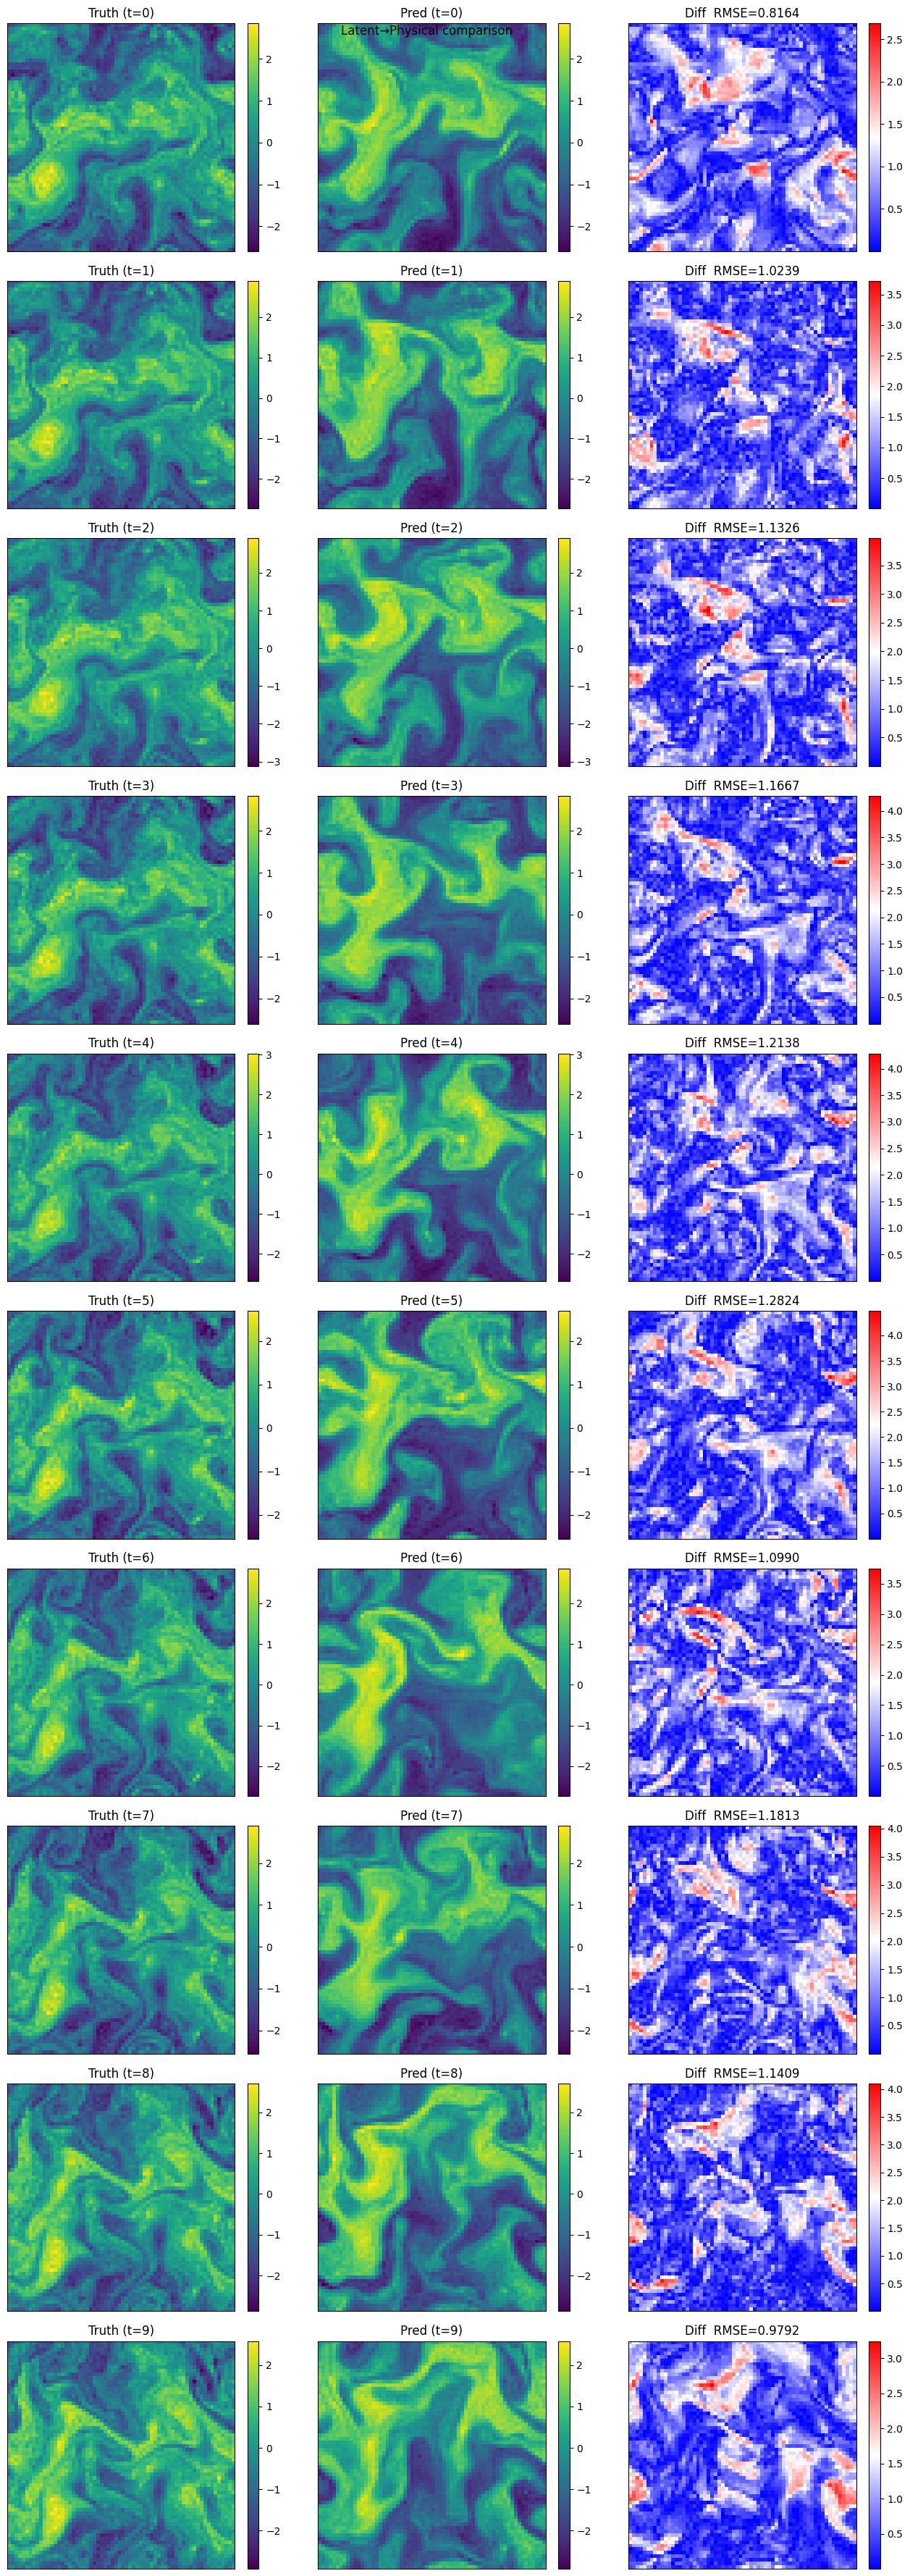

(1.1108700037002563,
 array([0.8164075, 1.0239215, 1.1326306, 1.1666507, 1.2138207, 1.2823793,
        1.0989977, 1.1812718, 1.1409012, 0.9791573], dtype=float32))

In [10]:
visualize_and_rmse(y_hats, ys_norm)

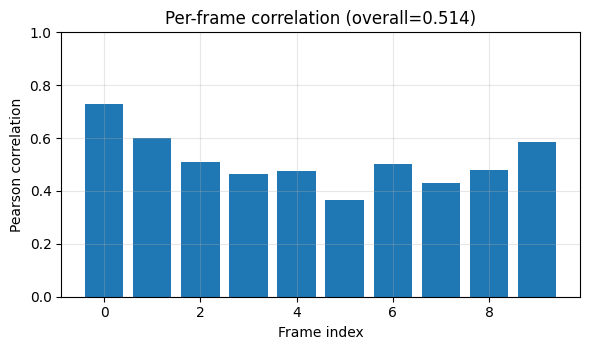

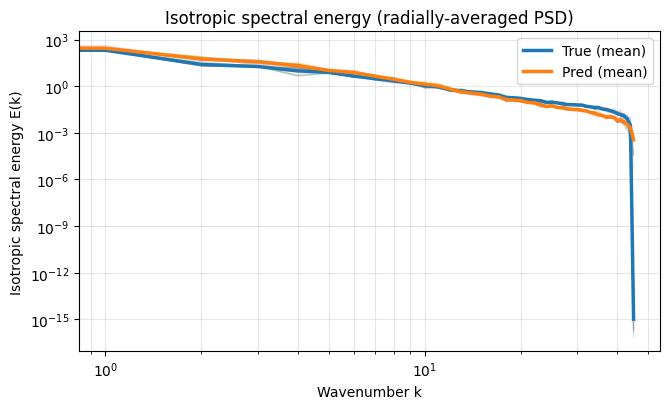

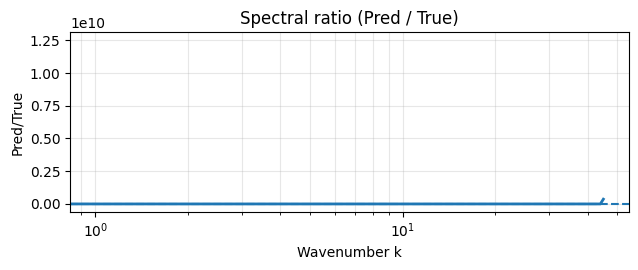

(0.5138927698135376,
 array([0.72820807, 0.6005936 , 0.5086621 , 0.46430606, 0.47501317,
        0.36451927, 0.5012862 , 0.4298286 , 0.47944918, 0.5870607 ],
       dtype=float32),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45.], dtype=float32),
 array([1.39433224e-14, 2.06285032e+02, 2.51034751e+01, 1.84533235e+01,
        9.73350053e+00, 7.74209805e+00, 4.44956537e+00, 3.04263965e+00,
        2.18031534e+00, 1.60748567e+00, 1.04533516e+00, 9.12491480e-01,
        5.66107365e-01, 5.10301605e-01, 4.23099831e-01, 3.87755214e-01,
        3.20192186e-01, 2.67751130e-01, 1.91953784e-01, 1.79073881e-01,
        1.61574595e-01, 1.39398600e-01, 1.24685676e-01, 1.17238752e-01,
        9.21677022e-02, 9.34571009e-02, 8.37752130e-02, 7.49316743e-02,
        6.53838905e-02, 6.51258201e-

In [11]:
visualize_corr_and_spectrum(y_hats, ys_norm)

[RMSE] overall = 0.892655
[RMSE] per-frame: [0.      , 0.754143, 0.961218, 1.078018, 1.088292, 1.147194, 1.091008,
 0.989547, 0.802247, 0.      ]


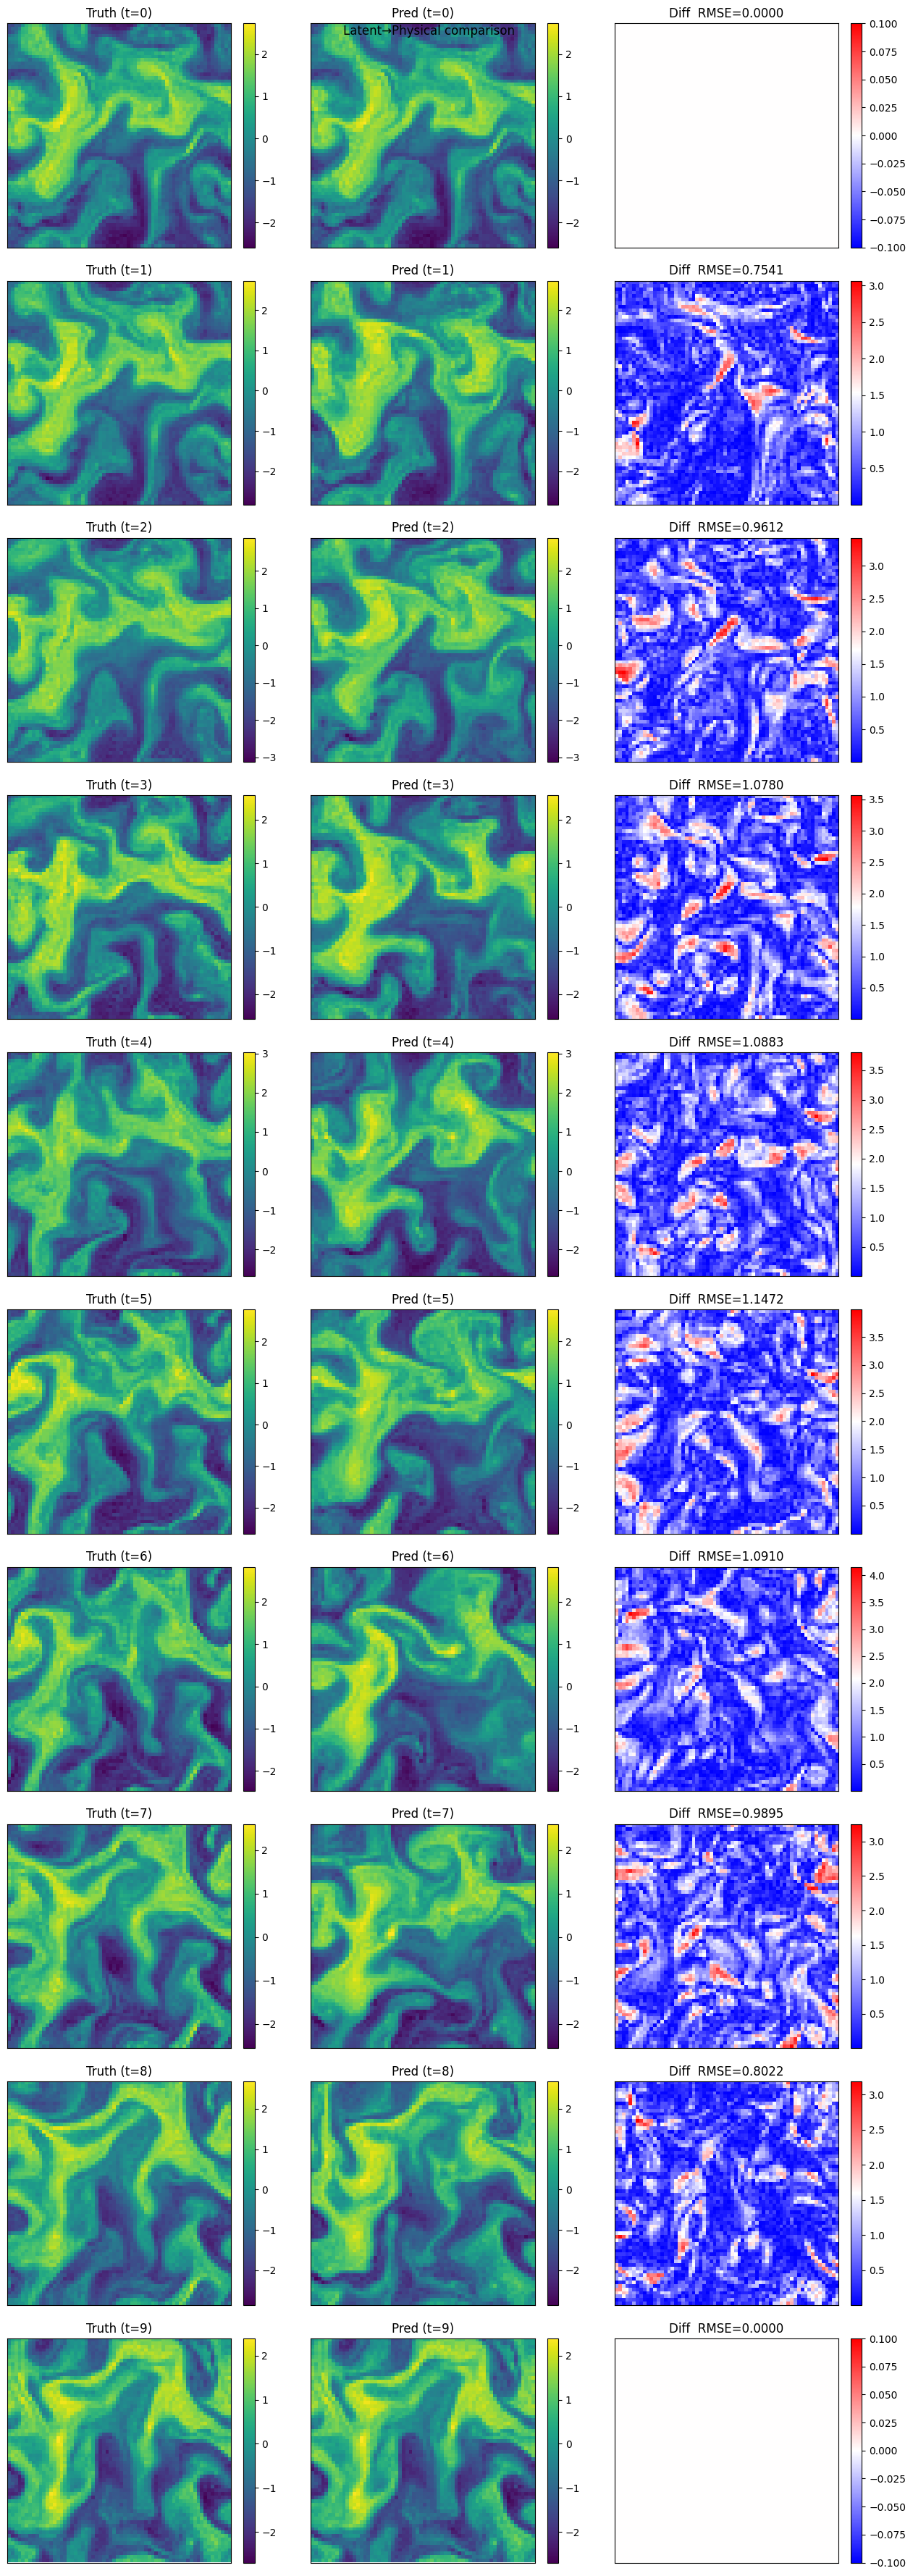

(0.8926548361778259,
 array([0.        , 0.7541432 , 0.9612175 , 1.0780178 , 1.0882919 ,
        1.1471941 , 1.0910076 , 0.98954654, 0.8022469 , 0.        ],
       dtype=float32))

In [12]:
visualize_and_rmse(y_hats, ys_baseline)

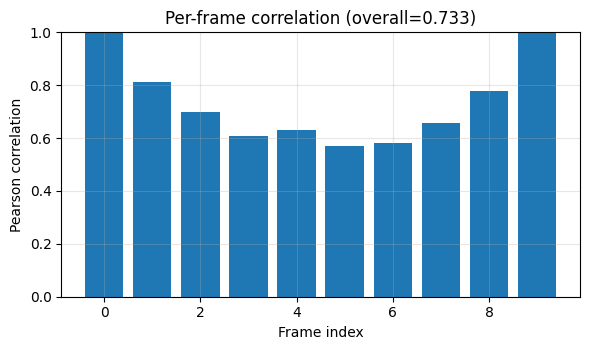

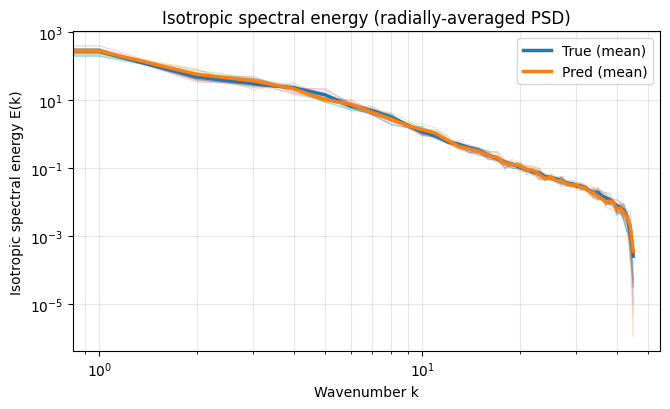

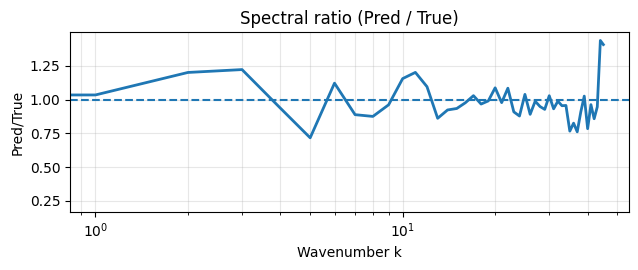

In [13]:
bigger_ppl_result = visualize_corr_and_spectrum(y_hats, ys_baseline)

In [31]:
import numpy as np


def path_length(ys_hat, ys):
    """
    Geometry continuity metric: path length.

    Args:
        ys_hat: interpolated path, shape (K, 64, 64)
        ys: reference true/sampled path, shape (K, 64, 64)

    Returns:
        dict with:
          - L_hat: path length of ys_hat
          - L_true: path length of ys
          - ratio: L_hat / (L_true + eps)
          - step_norms_hat: array of per-step norms for ys_hat (length K-1)
          - step_norms_true: array of per-step norms for ys (length K-1)
    """
    # vectorize
    vhat = ys_hat.reshape(ys_hat.shape[0], -1)  # (K, 64*64)
    vref = ys.reshape(ys.shape[0], -1)

    # increments
    dhat = vhat[1:] - vhat[:-1]  # (K-1, D)
    dref = vref[1:] - vref[:-1]

    # per-step L2 norms
    step_hat = np.linalg.norm(dhat, axis=1)
    step_ref = np.linalg.norm(dref, axis=1)

    L_hat = float(step_hat.sum())
    L_true = float(step_ref.sum())

    eps = 1e-12
    ratio = float(L_hat / (L_true + eps))

    return {
        "L_hat": L_hat,
        "L_true": L_true,
        "ratio": ratio,
        "step_norms_hat": step_hat,
        "step_norms_true": step_ref,
    }

def discrete_turning_angle(ys_hat, ys):
    """
    Geometry continuity metric: discrete turning angle / curvature proxy.

    We compute:
        cos(theta_k) = <Δv_{k-1}, Δv_k> / (||Δv_{k-1}|| ||Δv_k|| + eps)
        C = mean(1 - cos(theta_k)), k=1..K-2

    Args:
        ys_hat: interpolated path, shape (K, 64, 64)
        ys: reference true/sampled path, shape (K, 64, 64)

    Returns:
        dict with:
          - C_hat: curvature score for ys_hat (lower is smoother)
          - C_true: curvature score for ys
          - ratio: C_hat / (C_true + eps)
          - cos_hat: array of cos(theta_k) for ys_hat (length K-2)
          - cos_true: array of cos(theta_k) for ys (length K-2)
    """

    vhat = ys_hat.reshape(ys_hat.shape[0], -1)
    vref = ys.reshape(ys.shape[0], -1)

    dhat = vhat[1:] - vhat[:-1]  # (K-1, D)
    dref = vref[1:] - vref[:-1]

    # consecutive pairs: (Δv_{k-1}, Δv_k) for k=1..K-2
    a_hat, b_hat = dhat[:-1], dhat[1:]  # each (K-2, D)
    a_ref, b_ref = dref[:-1], dref[1:]

    eps = 1e-12

    # dot products
    dot_hat = np.sum(a_hat * b_hat, axis=1)
    dot_ref = np.sum(a_ref * b_ref, axis=1)

    # norms
    na_hat = np.linalg.norm(a_hat, axis=1)
    nb_hat = np.linalg.norm(b_hat, axis=1)
    na_ref = np.linalg.norm(a_ref, axis=1)
    nb_ref = np.linalg.norm(b_ref, axis=1)

    cos_hat = dot_hat / (na_hat * nb_hat + eps)
    cos_ref = dot_ref / (na_ref * nb_ref + eps)

    # numerical safety: clamp to [-1, 1]
    cos_hat = np.clip(cos_hat, -1.0, 1.0)
    cos_ref = np.clip(cos_ref, -1.0, 1.0)

    C_hat = float(np.mean(1.0 - cos_hat))
    C_true = float(np.mean(1.0 - cos_ref))

    ratio = float(C_hat / (C_true + eps))

    return {
        "C_hat": C_hat,
        "C_true": C_true,
        "ratio": ratio,
        "cos_hat": cos_hat,
        "cos_true": cos_ref,
    }


In [15]:
pl = path_length(y_hats, ys_baseline)
dta = discrete_turning_angle(y_hats, ys_baseline)

In [16]:
print(pl)
print(dta)

{'L_hat': 430.49493408203125, 'L_true': 360.1362609863281, 'ratio': 1.1953668117256677, 'step_norms_hat': array([35.600086, 42.733913, 47.86966 , 55.651608, 55.147804, 51.723537,
       50.095963, 53.328884, 38.34346 ], dtype=float32), 'step_norms_true': array([36.364296, 38.238525, 39.832256, 42.594635, 44.108208, 39.461483,
       42.843952, 36.93537 , 39.757526], dtype=float32)}
{'C_hat': 1.43896484375, 'C_true': 0.9772816896438599, 'ratio': 1.4724156392134125, 'cos_hat': array([-0.54954624, -0.30823308, -0.45903245, -0.49508148, -0.45089594,
       -0.6095177 , -0.3816663 , -0.25774512], dtype=float32), 'cos_true': array([ 0.06658717,  0.02379491, -0.11249258,  0.00281548,  0.02028657,
        0.05800183,  0.06889244,  0.05386058], dtype=float32)}


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- helpers: ACF + radial average + xi ----------
def _standardize_frame(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """Per-frame standardization (z-score)."""
    x = np.asarray(x, dtype=np.float64)
    m = x.mean()
    s = x.std()
    return (x - m) / (s + eps)

def _acf2d_fft(x: np.ndarray) -> np.ndarray:
    """
    2D autocorrelation via FFT under periodic boundary (wrap).
    Returns ACF normalized so that ACF[0,0] = 1.
    """
    x = np.asarray(x, dtype=np.float64)
    H, W = x.shape
    F = np.fft.fft2(x)
    P = np.abs(F) ** 2
    acf = np.fft.ifft2(P).real / (H * W)  # unbiased up to constant; periodic assumption
    # normalize
    acf0 = acf[0, 0]
    if acf0 == 0:
        return acf
    return acf / acf0

def _radial_average_2d(field2d: np.ndarray) -> np.ndarray:
    """
    Radial average of a 2D field around (0,0) in periodic grid index distance.
    We use distance in index space: r = sqrt(dx^2 + dy^2) where dx,dy are wrapped to [-H/2,H/2].
    Returns radial profile R[r_int], r_int = 0..r_max (integer bins).
    """
    f = np.asarray(field2d, dtype=np.float64)
    H, W = f.shape

    # build wrapped coordinates centered at 0
    dy = np.arange(H)
    dx = np.arange(W)
    dy = np.minimum(dy, H - dy)  # wrap distance to 0
    dx = np.minimum(dx, W - dx)

    DX, DY = np.meshgrid(dx, dy)
    R = np.sqrt(DX**2 + DY**2)

    r_int = np.floor(R).astype(np.int32)
    r_max = r_int.max()

    num = np.bincount(r_int.ravel(), weights=f.ravel(), minlength=r_max + 1)
    den = np.bincount(r_int.ravel(), minlength=r_max + 1)
    prof = np.zeros(r_max + 1, dtype=np.float64)
    mask = den > 0
    prof[mask] = num[mask] / den[mask]
    return prof

def _xi_from_radial_profile(Rr: np.ndarray, threshold: float = np.exp(-1), r_min: int = 1) -> float:
    """
    Correlation length xi as first radius where R(r) <= threshold.
    If never crosses, return max r.
    """
    Rr = np.asarray(Rr, dtype=np.float64)
    # start from r_min to ignore r=0 (always 1 after normalization)
    for r in range(max(r_min, 1), len(Rr)):
        if Rr[r] <= threshold:
            return float(r)
    return float(len(Rr) - 1)

def _xi_for_frame(x: np.ndarray) -> float:
    """
    Full pipeline: standardize -> ACF2D -> radial average -> xi.
    """
    xs = _standardize_frame(x)
    acf2d = _acf2d_fft(xs)
    Rr = _radial_average_2d(acf2d)
    return _xi_from_radial_profile(Rr)


# ---------- metric 1: dataset-level xi distribution ----------
def xi_distribution(ys, ci: float = 0.90, max_frames: int | None = None, seed: int = 0):
    """
    ys: array of frames, shape (N, 64, 64) or (N, 2, 64, 64) or (64,64)/(2,64,64)
        - If 4D with 2 levels, we compute xi per level and average them per frame.

    Returns:
        dict with:
          - xi_values: (N,) xi per frame
          - ci_low, ci_high: CI bounds (percentile-based)
          - median, mean, std
          - ci: confidence level used
    """
    rng = np.random.default_rng(seed)
    ys = np.asarray(ys)

    # Promote single frame
    if ys.ndim == 2:
        ys = ys[None, ...]  # (1,H,W)
    elif ys.ndim == 3:
        # (N,H,W) or (2,H,W) ambiguous; assume first dim is N if equals 64 not.
        if ys.shape[0] == 2 and ys.shape[1:] == (64, 64):
            ys = ys[None, ...]  # (1,2,64,64)
    elif ys.ndim == 4:
        pass
    else:
        raise ValueError(f"ys must be 2D/3D/4D, got shape {ys.shape}")

    # Optionally subsample frames for speed
    N = ys.shape[0]
    idx = np.arange(N)
    if max_frames is not None and N > max_frames:
        idx = rng.choice(idx, size=max_frames, replace=False)
        idx = np.sort(idx)

    xis = []
    for i in idx:
        frame = ys[i]
        if frame.ndim == 3:  # (2,64,64)
            xi_levels = [_xi_for_frame(frame[l]) for l in range(frame.shape[0])]
            xis.append(float(np.mean(xi_levels)))
        else:  # (64,64)
            xis.append(_xi_for_frame(frame))

    xi_values = np.asarray(xis, dtype=np.float64)

    alpha = 1.0 - ci
    ci_low = float(np.quantile(xi_values, alpha / 2))
    ci_high = float(np.quantile(xi_values, 1.0 - alpha / 2))

    return {
        "xi_values": xi_values,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "median": float(np.median(xi_values)),
        "mean": float(np.mean(xi_values)),
        "std": float(np.std(xi_values)),
        "ci": ci,
        "n_used": int(len(xi_values)),
    }


# ---------- metric 2: comparison for interpolation path ----------
def spatial_autocorrelation_comparison(xi_ci, y_hats):
    """
    Dataset-level metric:
      - Compute ξ_k for each interpolated frame y_hats[k]
      - Compare against CI band [ci_low, ci_high] from xi_distribution on TRUE dataset
      - Plot ξ_k curve with CI band
      - Return pass_rate and ξ_k

    Args:
        xi_ci: dict returned by xi_distribution (must include ci_low, ci_high)
        y_hats: interpolated frames, shape (K,64,64) or (K,2,64,64) or (64,64)/(2,64,64)

    Returns:
        dict with:
          - xi_hat: (K,) xi along interpolation path
          - pass_mask: (K,) boolean
          - pass_rate: float
          - ci_low, ci_high: floats
    """
    if not isinstance(xi_ci, dict) or "ci_low" not in xi_ci or "ci_high" not in xi_ci:
        raise ValueError("xi_ci must be the dict returned by xi_distribution and contain ci_low/ci_high")

    ci_low = float(xi_ci["ci_low"])
    ci_high = float(xi_ci["ci_high"])

    y_hats = np.asarray(y_hats)

    # Promote single frame
    if y_hats.ndim == 2:
        y_hats = y_hats[None, ...]  # (1,H,W)
    elif y_hats.ndim == 3:
        if y_hats.shape[0] == 2 and y_hats.shape[1:] == (64, 64):
            y_hats = y_hats[None, ...]  # (1,2,64,64)
    elif y_hats.ndim == 4:
        pass
    else:
        raise ValueError(f"y_hats must be 2D/3D/4D, got shape {y_hats.shape}")

    K = y_hats.shape[0]
    xi_hat = np.zeros(K, dtype=np.float64)

    for k in range(K):
        frame = y_hats[k]
        if frame.ndim == 3:  # (2,64,64)
            xi_levels = [_xi_for_frame(frame[l]) for l in range(frame.shape[0])]
            xi_hat[k] = float(np.mean(xi_levels))
        else:
            xi_hat[k] = _xi_for_frame(frame)

    pass_mask = (xi_hat >= ci_low) & (xi_hat <= ci_high)
    pass_rate = float(np.mean(pass_mask))

    return {
        "xi_hat": xi_hat,
        "pass_mask": pass_mask,
        "pass_rate": pass_rate,
        "ci_low": ci_low,
        "ci_high": ci_high,
    }


In [18]:
xi_ci = xi_distribution(data_phy, ci=0.90)
out = spatial_autocorrelation_comparison(xi_ci, y_hats)

In [33]:
# =========================
# 0) Utility: reproducibility
# =========================

def set_global_seed(seed: int):
    """
    Set random seeds for numpy/torch (if torch exists in scope).
    No imports inside.
    """
    np.random.seed(seed)
    if "torch" in globals():
        try:
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
        except Exception:
            pass


def sample_start_indices(T: int, gap: int, repeat: int, seed: int = 0):
    """
    Sample 'repeat' start indices t such that t + gap < T.
    Returns: np.ndarray shape (repeat,)
    """
    rng = np.random.default_rng(seed)
    max_start = T - gap - 1
    if max_start < 0:
        raise ValueError(f"gap={gap} is too large for T={T} (need T >= gap+1).")

    candidates = np.arange(max_start + 1, dtype=np.int64)

    # if not enough candidates, sample with replacement
    replace = (len(candidates) < repeat)
    starts = rng.choice(candidates, size=repeat, replace=replace)
    starts = starts.astype(np.int64)
    return starts


# =========================
# 1) Sampler factory (members must match frames)
# =========================

def make_sampler_with_members(members: int):
    """
    Create a new Sampler whose 'members' equals number of frames (K = gap+1).
    Uses global variables defined in interpolation.py (model_path, device, steps, invert_steps, etc.).
    No imports inside.
    """
    if "Sampler" not in globals():
        raise RuntimeError("Sampler is not available in globals. Make sure interpolation.py executed.")

    # Use globals if present; otherwise fall back to safe defaults.
    _device = device if "device" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
    _model_path = model_path if "model_path" in globals() else "../best_model.pth"
    _steps = steps if "steps" in globals() else 100
    _invert_steps = invert_steps if "invert_steps" in globals() else 100
    _debug = debug if "debug" in globals() else False
    _deterministic = deterministic if "deterministic" in globals() else True

    # eps functions (must exist or create simple ones)
    _zero_eps = zero_eps if "zero_eps" in globals() else (lambda t: 0.0)

    # NOTE: Sampler signature in your file:
    # Sampler(device, members, eps, steps, invert_eps, invert_steps, model_path, debug, deterministic)
    s = Sampler(_device, members, _zero_eps, _steps, _zero_eps, _invert_steps, _model_path, _debug, _deterministic)
    return s


# =========================
# 2) Core interpolation runners
# =========================

def run_linear_latent_path(latent_data, start: int, end: int):
    """
    Linear interpolation in latent space.
    Returns: z_hat (K, H, W) where K = end-start+1
    """
    return linear_interpolation(latent_data, start=start, end=end)


def run_stochastic_latent_paths(latent_data, start: int, end: int, M: int, seed: int = 0):
    """
    Stochastic interpolation in latent space, M paths.
    Returns: z_hats (M, K, H, W)
    """
    # Ensure reproducibility across runs if needed
    set_global_seed(seed)
    return stochastic_interpolation(latent_data, n=M, start=start, end=end)


def latent_segment_truth(latent_data, start: int, end: int):
    """
    Extract truth latent segment z_true: (K, H, W)
    """
    return latent_data[start:end+1].astype(np.float32)


def physical_segment_truth(phys_data, start: int, end: int):
    """
    Extract truth physical segment x_true: (K, H, W)
    """
    return phys_data[start:end+1].astype(np.float32)


def map_latent_path_to_physical(z_path, sampler_obj, data_std_val=1.0, device_str=None):
    """
    Map latent path z_path -> x_hat using map_latent_to_physical.
    z_path: (K, H, W)
    Returns: x_hat (K, H, W)
    """
    if device_str is None:
        device_str = "cuda" if ("torch" in globals() and torch.cuda.is_available()) else "cpu"
    return map_latent_to_physical(z_path, sampler_obj, device=device_str, data_std=data_std_val, return_torch=False)


# =========================
# 3) Metrics (no plotting by default)
# =========================

def pearson_corr_per_frame(pred, true):
    """
    Compute Pearson correlation per frame, aligned.
    pred,true: (K,H,W)
    Returns: (overall_corr, per_frame_corr)
    """
    pred = pred.astype(np.float32)
    true = true.astype(np.float32)
    if pred.shape != true.shape:
        raise ValueError(f"Shape mismatch in pearson_corr_per_frame: {pred.shape} vs {true.shape}")

    K = pred.shape[0]
    per = np.zeros(K, dtype=np.float32)
    for k in range(K):
        a = true[k].ravel()
        b = pred[k].ravel()
        a = a - a.mean()
        b = b - b.mean()
        denom = np.linalg.norm(a) * np.linalg.norm(b)
        per[k] = 0.0 if denom == 0 else float(np.dot(a, b) / denom)
    return float(per.mean()), per


def rmse_per_frame(pred, true):
    """
    RMSE per frame, aligned.
    pred,true: (K,H,W)
    Returns: (overall_rmse, per_frame_rmse)
    """
    pred = pred.astype(np.float32)
    true = true.astype(np.float32)
    if pred.shape != true.shape:
        raise ValueError(f"Shape mismatch in rmse_per_frame: {pred.shape} vs {true.shape}")

    diff = pred - true
    per = np.sqrt(np.mean(diff**2, axis=(1, 2))).astype(np.float32)
    overall = float(np.sqrt(np.mean(diff**2)))
    return overall, per


def geometry_metrics(pred_path, ref_path):
    """
    Geometry continuity metrics using your existing:
      - path_length
      - discrete_turning_angle
    Each returns dict with ratio etc.
    """
    pl = path_length(pred_path, ref_path)
    dta = discrete_turning_angle(pred_path, ref_path)
    return {
        "path_length": pl,
        "turning_angle": dta,
    }


# =========================
# 4) Evaluate one segment (one start, one gap)
# =========================

def evaluate_one_segment(
    latent_data,
    phys_data,
    start: int,
    gap: int,
    method: str,
    M: int,
    xi_ci_phys,
    data_std_val=1.0,
    seed_base: int = 0,
):
    """
    Evaluate a single (start, gap) segment for a given method.
    Returns a dict with:
      - latent comparisons (vs truth latent)
      - physical comparisons (vs truth physical)
      - geometry metrics in physical space (pred physical vs ref physical)
      - xi pass rate (physical)
    """
    end = start + gap
    K = gap + 1

    # truth segments
    z_true = latent_segment_truth(latent_data, start, end)       # (K,H,W)
    x_true = physical_segment_truth(phys_data, start, end)       # (K,H,W)

    # sampler must match frames
    sampler_obj = make_sampler_with_members(K)

    out = {
        "start": int(start),
        "gap": int(gap),
        "K": int(K),
        "method": method,
    }

    if method == "linear":
        # --- latent path ---
        z_hat = run_linear_latent_path(latent_data, start, end)  # (K,H,W)
        # --- physical path ---
        x_hat = map_latent_path_to_physical(z_hat, sampler_obj, data_std_val=data_std_val)

        # latent dynamics consistency (aligned to truth latent)
        z_corr_mean, z_corr = pearson_corr_per_frame(z_hat, z_true)
        z_rmse_mean, z_rmse = rmse_per_frame(z_hat, z_true)

        # physical dynamics consistency (aligned to truth physical)
        x_corr_mean, x_corr = pearson_corr_per_frame(x_hat, x_true)
        x_rmse_mean, x_rmse = rmse_per_frame(x_hat, x_true)

        # geometry continuity (physical space), compare to truth physical path
        geom = geometry_metrics(x_hat, x_true)

        # physical consistency via xi CI band (dataset-level)
        xi_cmp = spatial_autocorrelation_comparison(xi_ci_phys, x_hat)  # will plot
        # If you want to avoid plots, comment above and compute xi directly using _xi_for_frame.
        # But you explicitly said this file contains all needed code, so we keep it.

        out.update({
            "z_hat": z_hat,
            "x_hat": x_hat,
            "latent_consistency": {"corr_mean": z_corr_mean, "corr": z_corr, "rmse_mean": z_rmse_mean, "rmse": z_rmse},
            "physical_consistency_aligned": {"corr_mean": x_corr_mean, "corr": x_corr, "rmse_mean": x_rmse_mean, "rmse": x_rmse},
            "geometry": geom,
            "xi_consistency": {"pass_rate": float(xi_cmp["pass_rate"]), "xi_hat": xi_cmp["xi_hat"]},
        })
        return out

    elif method == "stochastic":
        # --- M latent paths ---
        z_hats = run_stochastic_latent_paths(latent_data, start, end, M=M, seed=seed_base + start + gap)  # (M,K,H,W)

        # Collect per-path metrics, then average over M
        z_corr_means = []
        z_rmse_means = []
        x_corr_means = []
        x_rmse_means = []
        L_ratios = []
        C_ratios = []
        xi_pass_rates = []

        # Optionally keep one representative path for debugging/visualization
        z_hat0 = None
        x_hat0 = None

        for m in range(M):
            z_hat = z_hats[m]
            x_hat = map_latent_path_to_physical(z_hat, sampler_obj, data_std_val=data_std_val)

            if m == 0:
                z_hat0 = z_hat
                x_hat0 = x_hat

            # latent vs truth latent
            z_corr_mean, _ = pearson_corr_per_frame(z_hat, z_true)
            z_rmse_mean, _ = rmse_per_frame(z_hat, z_true)

            # physical vs truth physical
            x_corr_mean, _ = pearson_corr_per_frame(x_hat, x_true)
            x_rmse_mean, _ = rmse_per_frame(x_hat, x_true)

            # geometry in physical space
            geom = geometry_metrics(x_hat, x_true)
            L_ratios.append(float(geom["path_length"]["ratio"]))
            C_ratios.append(float(geom["turning_angle"]["ratio"]))

            # xi CI consistency (will plot each time; if too much, only do m==0)
            xi_cmp = spatial_autocorrelation_comparison(xi_ci_phys, x_hat)

            xi_pass_rates.append(float(xi_cmp["pass_rate"]))

            z_corr_means.append(float(z_corr_mean))
            z_rmse_means.append(float(z_rmse_mean))
            x_corr_means.append(float(x_corr_mean))
            x_rmse_means.append(float(x_rmse_mean))

        out.update({
            "z_hat": z_hat0,
            "x_hat": x_hat0,
            "stochastic_M": int(M),

            "latent_consistency": {
                "corr_mean_M": float(np.mean(z_corr_means)),
                "corr_std_M": float(np.std(z_corr_means)),
                "rmse_mean_M": float(np.mean(z_rmse_means)),
                "rmse_std_M": float(np.std(z_rmse_means)),
            },
            "physical_consistency_aligned": {
                "corr_mean_M": float(np.mean(x_corr_means)),
                "corr_std_M": float(np.std(x_corr_means)),
                "rmse_mean_M": float(np.mean(x_rmse_means)),
                "rmse_std_M": float(np.std(x_rmse_means)),
            },
            "geometry": {
                "path_length_ratio_mean_M": float(np.mean(L_ratios)),
                "path_length_ratio_std_M": float(np.std(L_ratios)),
                "turning_ratio_mean_M": float(np.mean(C_ratios)),
                "turning_ratio_std_M": float(np.std(C_ratios)),
            },
            "xi_consistency": {
                "pass_rate_mean_M": float(np.mean(xi_pass_rates)),
                "pass_rate_std_M": float(np.std(xi_pass_rates)),
            },
        })
        return out

    else:
        raise ValueError(f"Unknown method: {method}. Use 'linear' or 'stochastic'.")


# =========================
# 5) Run the final experiment
# =========================

def run_final_experiment(
    gap_list,
    latent_data,
    phys_data,
    repeat: int = 30,
    M: int = 3,
    seed: int = 0,
    data_std_val: float = 1.0,
):
    """
    Final experiment:
      1) gap_list sweep
      2) random start indices (repeat)
      3) linear & stochastic (M paths)
      4) evaluate: geometry continuity, physical consistency, dynamics consistency
      5) compare to truth latent and truth physical

    Returns:
      results: dict indexed by gap -> method -> list of segment outputs
      summary: dict indexed by gap -> method -> aggregated means
    """
    set_global_seed(seed)

    T = latent_data.shape[0]
    results = {}
    summary = {}

    # dataset-level CI for xi (physical truth)
    xi_ci_phys = xi_distribution(phys_data, ci=0.90)

    for gap in gap_list:
        gap = int(gap)
        results[gap] = {"linear": [], "stochastic": []}

        # sample starts (paired design: same starts for both methods)
        starts = sample_start_indices(T=T, gap=gap, repeat=repeat, seed=seed + gap)

        # ---- linear ----
        for idx, t0 in enumerate(starts):
            seg = evaluate_one_segment(
                latent_data=latent_data,
                phys_data=phys_data,
                start=int(t0),
                gap=gap,
                method="linear",
                M=1,
                xi_ci_phys=xi_ci_phys,
                data_std_val=data_std_val,
                seed_base=seed + idx,
            )
            results[gap]["linear"].append(seg)

        # ---- stochastic ----
        for idx, t0 in enumerate(starts):
            seg = evaluate_one_segment(
                latent_data=latent_data,
                phys_data=phys_data,
                start=int(t0),
                gap=gap,
                method="stochastic",
                M=M,
                xi_ci_phys=xi_ci_phys,
                data_std_val=data_std_val,
                seed_base=seed + 1000 + idx,
            )
            results[gap]["stochastic"].append(seg)

        # ---- aggregate summary (simple) ----
        summary[gap] = {}

        for method in ["linear", "stochastic"]:
            segs = results[gap][method]

            if method == "linear":
                z_corr = np.array([s["latent_consistency"]["corr_mean"] for s in segs], dtype=np.float64)
                x_corr = np.array([s["physical_consistency_aligned"]["corr_mean"] for s in segs], dtype=np.float64)
                L_ratio = np.array([s["geometry"]["path_length"]["ratio"] for s in segs], dtype=np.float64)
                C_ratio = np.array([s["geometry"]["turning_angle"]["ratio"] for s in segs], dtype=np.float64)
                xi_pass = np.array([s["xi_consistency"]["pass_rate"] for s in segs], dtype=np.float64)

                summary[gap][method] = {
                    "latent_corr_mean": float(z_corr.mean()),
                    "latent_corr_std": float(z_corr.std()),
                    "physical_corr_mean": float(x_corr.mean()),
                    "physical_corr_std": float(x_corr.std()),
                    "path_length_ratio_mean": float(L_ratio.mean()),
                    "path_length_ratio_std": float(L_ratio.std()),
                    "turning_ratio_mean": float(C_ratio.mean()),
                    "turning_ratio_std": float(C_ratio.std()),
                    "xi_pass_rate_mean": float(xi_pass.mean()),
                    "xi_pass_rate_std": float(xi_pass.std()),
                    "repeat": int(len(segs)),
                }

            else:
                z_corr = np.array([s["latent_consistency"]["corr_mean_M"] for s in segs], dtype=np.float64)
                x_corr = np.array([s["physical_consistency_aligned"]["corr_mean_M"] for s in segs], dtype=np.float64)
                L_ratio = np.array([s["geometry"]["path_length_ratio_mean_M"] for s in segs], dtype=np.float64)
                C_ratio = np.array([s["geometry"]["turning_ratio_mean_M"] for s in segs], dtype=np.float64)
                xi_pass = np.array([s["xi_consistency"]["pass_rate_mean_M"] for s in segs], dtype=np.float64)

                summary[gap][method] = {
                    "latent_corr_mean": float(z_corr.mean()),
                    "latent_corr_std": float(z_corr.std()),
                    "physical_corr_mean": float(x_corr.mean()),
                    "physical_corr_std": float(x_corr.std()),
                    "path_length_ratio_mean": float(L_ratio.mean()),
                    "path_length_ratio_std": float(L_ratio.std()),
                    "turning_ratio_mean": float(C_ratio.mean()),
                    "turning_ratio_std": float(C_ratio.std()),
                    "xi_pass_rate_mean": float(xi_pass.mean()),
                    "xi_pass_rate_std": float(xi_pass.std()),
                    "repeat": int(len(segs)),
                    "M": int(M),
                }

    return results, summary





In [34]:
# =========================
# 6) Example usage
# =========================
gap_list = [5, 10, 20, 30, 50]
results, summary = run_final_experiment(
    gap_list=gap_list,
    latent_data=data,     # your inverted/latent dataset
    phys_data=data_phy,   # truth physical dataset
    repeat=30,
    M=3,
    seed=0,
    data_std_val=1.0,     # adjust if needed (your file sometimes uses 2660.0)
)
print(summary)

{5: {'linear': {'latent_corr_mean': 0.4000817130009333, 'latent_corr_std': 0.018380628811570536, 'physical_corr_mean': 0.6300993263721466, 'physical_corr_std': 0.1750531061659277, 'path_length_ratio_mean': 0.7524205906061102, 'path_length_ratio_std': 0.12776213380569357, 'turning_ratio_mean': 0.637350707466025, 'turning_ratio_std': 0.07174419549329639, 'xi_pass_rate_mean': 0.9611111111111111, 'xi_pass_rate_std': 0.08258927081843613, 'repeat': 30}, 'stochastic': {'latent_corr_mean': 0.3936442381805844, 'latent_corr_std': 0.016689103499032562, 'physical_corr_mean': 0.5882501938276821, 'physical_corr_std': 0.15244038013025266, 'path_length_ratio_mean': 1.8116813172028938, 'path_length_ratio_std': 0.41127056939204043, 'turning_ratio_mean': 1.4245744253463202, 'turning_ratio_std': 0.12682657924387833, 'xi_pass_rate_mean': 0.9370370370370371, 'xi_pass_rate_std': 0.09806075773980541, 'repeat': 30, 'M': 3}}, 10: {'linear': {'latent_corr_mean': 0.22768981903791427, 'latent_corr_std': 0.01047765

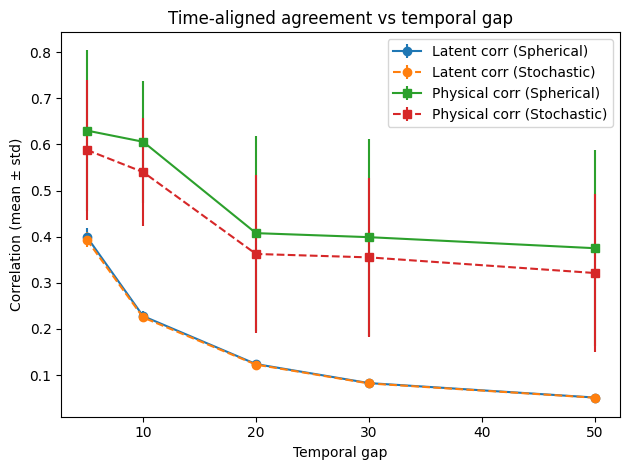

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Assumes your dict is already loaded as: summary
# summary: {gap: {'linear': {...}, 'stochastic': {...}}, ...}
# NOTE: summary['linear'] actually corresponds to *spherical* interpolation.

def _sorted_gaps(summary_dict):
    return np.array(sorted(summary_dict.keys()), dtype=int)

def _get_metric(summary_dict, method_key, metric_key):
    gaps = _sorted_gaps(summary_dict)
    vals = np.array([summary_dict[g][method_key][metric_key] for g in gaps], dtype=float)
    stds = np.array([summary_dict[g][method_key].get(metric_key.replace("_mean", "_std"), np.nan) for g in gaps], dtype=float)
    return gaps, vals, stds

# -----------------------------
# Figure 1: Time-aligned agreement vs temporal gap
#   - latent_corr_mean
#   - physical_corr_mean
# compare spherical (method_key='linear') vs stochastic
# -----------------------------
gaps = _sorted_gaps(summary)

# latent correlation
_, latent_sph, latent_sph_std = _get_metric(summary, "linear", "latent_corr_mean")
_, latent_sto, latent_sto_std = _get_metric(summary, "stochastic", "latent_corr_mean")

# physical correlation
_, phys_sph, phys_sph_std = _get_metric(summary, "linear", "physical_corr_mean")
_, phys_sto, phys_sto_std = _get_metric(summary, "stochastic", "physical_corr_mean")

plt.figure()
plt.errorbar(gaps, latent_sph, yerr=latent_sph_std, marker="o", linestyle="-", label="Latent corr (Spherical)")
plt.errorbar(gaps, latent_sto, yerr=latent_sto_std, marker="o", linestyle="--", label="Latent corr (Stochastic)")
plt.errorbar(gaps, phys_sph,  yerr=phys_sph_std,  marker="s", linestyle="-", label="Physical corr (Spherical)")
plt.errorbar(gaps, phys_sto,  yerr=phys_sto_std,  marker="s", linestyle="--", label="Physical corr (Stochastic)")
plt.xlabel("Temporal gap")
plt.ylabel("Correlation (mean ± std)")
plt.title("Time-aligned agreement vs temporal gap")
plt.legend()
plt.tight_layout()
plt.show()


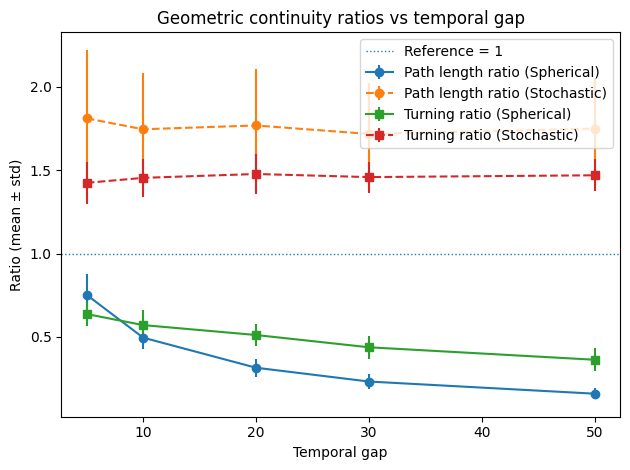

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Figure 2: Geometric continuity ratios vs temporal gap
#   - path_length_ratio_mean
#   - turning_ratio_mean
# compare spherical vs stochastic
# -----------------------------
gaps = np.array(sorted(summary.keys()), dtype=int)

# path length ratio
_, pl_sph, pl_sph_std = (gaps,
                         np.array([summary[g]["linear"]["path_length_ratio_mean"] for g in gaps], dtype=float),
                         np.array([summary[g]["linear"]["path_length_ratio_std"]  for g in gaps], dtype=float))
_, pl_sto, pl_sto_std = (gaps,
                         np.array([summary[g]["stochastic"]["path_length_ratio_mean"] for g in gaps], dtype=float),
                         np.array([summary[g]["stochastic"]["path_length_ratio_std"]  for g in gaps], dtype=float))

# turning ratio
_, tr_sph, tr_sph_std = (gaps,
                         np.array([summary[g]["linear"]["turning_ratio_mean"] for g in gaps], dtype=float),
                         np.array([summary[g]["linear"]["turning_ratio_std"]  for g in gaps], dtype=float))
_, tr_sto, tr_sto_std = (gaps,
                         np.array([summary[g]["stochastic"]["turning_ratio_mean"] for g in gaps], dtype=float),
                         np.array([summary[g]["stochastic"]["turning_ratio_std"]  for g in gaps], dtype=float))

plt.figure()
plt.errorbar(gaps, pl_sph, yerr=pl_sph_std, marker="o", linestyle="-",  label="Path length ratio (Spherical)")
plt.errorbar(gaps, pl_sto, yerr=pl_sto_std, marker="o", linestyle="--", label="Path length ratio (Stochastic)")
plt.errorbar(gaps, tr_sph, yerr=tr_sph_std, marker="s", linestyle="-",  label="Turning ratio (Spherical)")
plt.errorbar(gaps, tr_sto, yerr=tr_sto_std, marker="s", linestyle="--", label="Turning ratio (Stochastic)")
plt.axhline(1.0, linewidth=1.0, linestyle=":", label="Reference = 1")
plt.xlabel("Temporal gap")
plt.ylabel("Ratio (mean ± std)")
plt.title("Geometric continuity ratios vs temporal gap")
plt.legend()
plt.tight_layout()
plt.show()


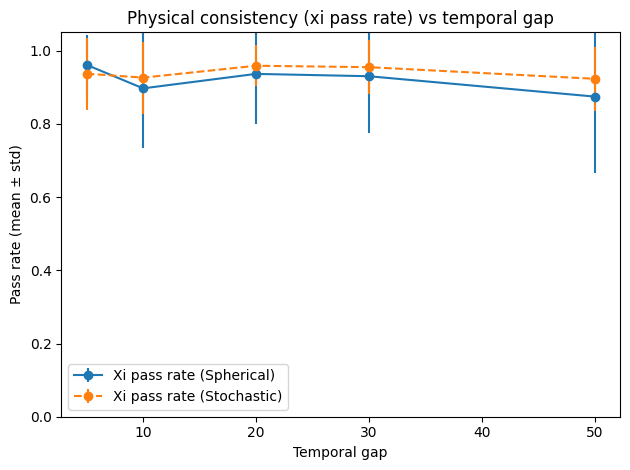

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Figure 3: Physical consistency (xi pass rate) vs temporal gap
#   - xi_pass_rate_mean
# compare spherical vs stochastic
# -----------------------------
gaps = np.array(sorted(summary.keys()), dtype=int)

xi_sph = np.array([summary[g]["linear"]["xi_pass_rate_mean"] for g in gaps], dtype=float)
xi_sph_std = np.array([summary[g]["linear"]["xi_pass_rate_std"] for g in gaps], dtype=float)

xi_sto = np.array([summary[g]["stochastic"]["xi_pass_rate_mean"] for g in gaps], dtype=float)
xi_sto_std = np.array([summary[g]["stochastic"]["xi_pass_rate_std"] for g in gaps], dtype=float)

plt.figure()
plt.errorbar(gaps, xi_sph, yerr=xi_sph_std, marker="o", linestyle="-",  label="Xi pass rate (Spherical)")
plt.errorbar(gaps, xi_sto, yerr=xi_sto_std, marker="o", linestyle="--", label="Xi pass rate (Stochastic)")
plt.xlabel("Temporal gap")
plt.ylabel("Pass rate (mean ± std)")
plt.ylim(0.0, 1.05)
plt.title("Physical consistency (xi pass rate) vs temporal gap")
plt.legend()
plt.tight_layout()
plt.show()
